# Remoção de ruídos e compactação

In [1]:
# Imports for Audio signal processing
from scipy.io.wavfile import read, write
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq, ifft
import sys

    
  


In [2]:
# converter audio.mp3 para audio.wav, se necessário
"""
from pydub import AudioSegment
sound = AudioSegment.from_mp3("audio.mp3")
sound.export("audio.wav", format="wav")
"""


'\nfrom pydub import AudioSegment\nsound = AudioSegment.from_mp3("audio.mp3")\nsound.export("audio.wav", format="wav")\n'

In [3]:
# Importar e mostrar audio original


# Import the .wav format audio into two variables: 
# sampling (int)
# audio signal (numpy array)

sampling, signal = read('audio.wav')


# time duration of the audio
length = signal.shape[0] / sampling

# x axis based on the time duration
time = np.linspace(0., length, signal.shape[0])


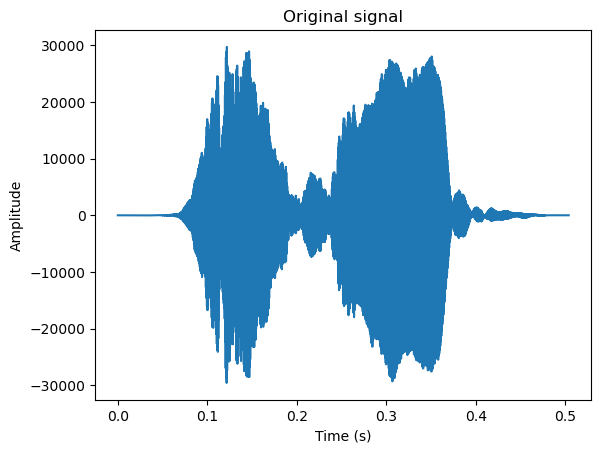

In [4]:
# plot do sinal original
plt.plot(time, signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original signal")
plt.show()

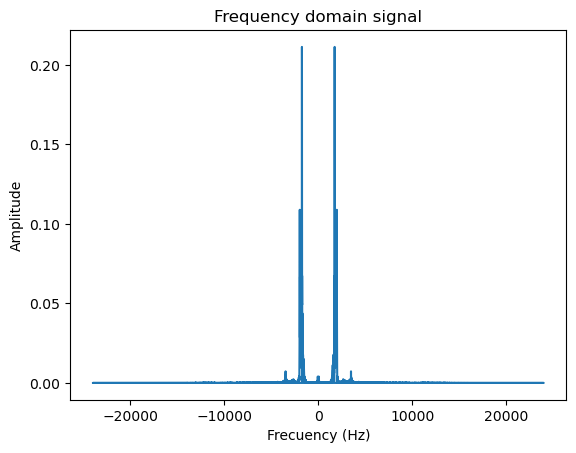

In [5]:
# Aplicar a transformada de fourier, normalizar e plotar
transform = fft(signal)

# obtain frequencies
xf = fftfreq(transform.size, 1/sampling) 

# show transformed signal (frequencies domain)
plt.plot(xf, abs(transform)/np.linalg.norm(transform))
plt.xlabel("Frecuency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency domain signal")
plt.show()

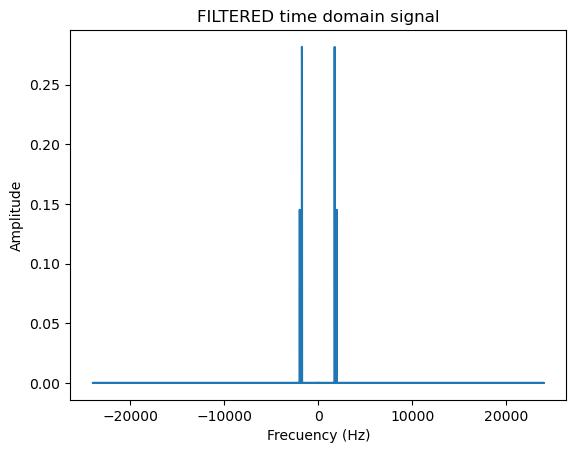

In [6]:
# filtrar a transformada do sinal para 40% da amplitude máxima
threshold = np.amax(transform)*0.4
filtered = np.copy(transform)
filtered[abs(transform) < 0.4 * max(abs(transform))] = 0



# Plotar a transformada filtrada
plt.plot(xf,abs(filtered)/np.linalg.norm(filtered))
plt.xlabel("Frecuency (Hz)")
plt.ylabel("Amplitude")
plt.title("FILTERED time domain signal")
plt.show()


/home/marcio/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/marcio/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


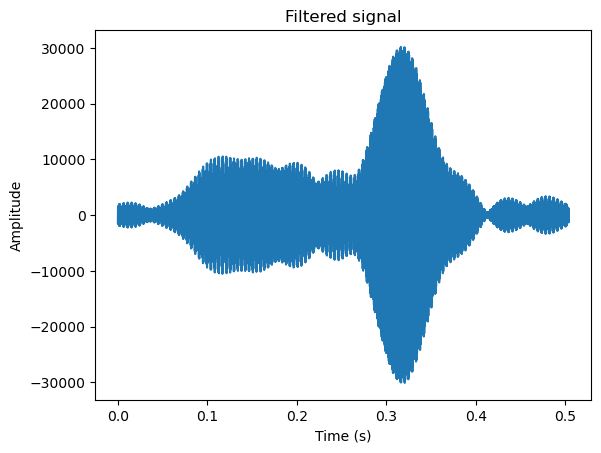

In [7]:
# reconstruir o audio a partir dos dados filtrados e plotar
filtered = ifft(filtered)

# show original signal filtered
plt.plot(time, filtered)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Filtered signal")
plt.show()

In [8]:
# Criar wav a partie do audio reconstruido

rate = 44100
write('test.wav', rate, signal)

In [9]:
# Exportar wav para mp3


#"""
from pydub import AudioSegment
sound = AudioSegment.from_mp3("test.wav")
sound.export("test.mp3", format="mp3")
#"""

<_io.BufferedRandom name='test.mp3'>